# Interactive Stock Performance & Risk Analysis Dashboard
## Project Highlights
-  User-centric: Built exclusively for non-technical retail investors
-  Interactive: Dynamic charts for intuitive data exploration
-  Practical: Focuses on actionable metrics used in real-world investing
## Problem Definition
This project addresses a critical pain point for retail investors: evaluating stock performance and risk often requires expensive professional tools or complex statistical knowledge. 

By building an interactive, no-code Python-based analysis tool, this project enables non-technical investors to quickly generate stock insights, visualize price trends, calculate key risk metrics, and make more informed investment decisions using publicly available data.

## Target User
The target users are individual retail investors who:

- Have basic stock market knowledge but no professional data analysis background  
- Cannot afford expensive financial tools or services  
- Want to conduct independent stock research quickly and objectively  
- Prefer intuitive visualizations over raw numerical data
## Analytical Focus
This project focuses on core financial indicators including stock returns, volatility, moving averages, and risk-adjusted returns (Sharpe Ratio) to help users assess profitability, risk levels, and overall market trends for improved investment decision-making.

In [3]:
import wrds
db=wrds.Connection()

Enter your WRDS username [13476]: songpudong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\13476\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [4]:
query = """
select permno, ticker, comnam
from crsp.stocknames
where ticker in ('AAPL','MSFT','TSLA','AMZN','NVDA')
"""
test = db.raw_sql(query)
test

,permno,ticker,comnam
0,10107,MSFT,MICROSOFT CORP
1,14593,AAPL,APPLE COMPUTER INC
2,14593,AAPL,APPLE INC
3,84788,AMZN,AMAZON COM INC
4,86580,NVDA,NVIDIA CORP
5,93436,TSLA,TESLA MOTORS INC
6,93436,TSLA,TESLA INC


In [20]:
query = """
select date, permno, prc, ret
from crsp.dsf
where permno in (14593, 10107, 93436, 84788, 86580)
and date between '2020-01-01' and '2024-01-01'
"""
data = db.raw_sql(query)

data.head()

,date,permno,prc,ret
0,2020-01-02,10107,160.62,0.018516
1,2020-01-03,10107,158.62,-0.012452
2,2020-01-06,10107,159.03,0.002585
3,2020-01-07,10107,157.58,-0.009118
4,2020-01-08,10107,160.09,0.015928


In [21]:
data["prc"] = abs(data["prc"])
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date")
data.head()

,date,permno,prc,ret
0,2020-01-02,10107,160.62,0.018516
3018,2020-01-02,86580,239.91,0.019592
2012,2020-01-02,84788,1898.01001,0.027151
4025,2020-01-02,93436,430.26001,0.028518
1006,2020-01-02,14593,300.35001,0.022816


## Data Collection & Cleaning


In [24]:
import pandas as pd
print("数据读取成功，共", len(data), "行")
print(data.head())

data = data.dropna(subset=["ret"])

data["date"] = pd.to_datetime(data["date"])

data = data.sort_values("date")

data = data.drop_duplicates()

data["prc"] = data["prc"].abs()

print("清洗完成，剩余", len(data), "行")
print(data.head())

数据读取成功，共 5030 行
           date  permno         prc       ret
0    2020-01-02   10107      160.62  0.018516
3018 2020-01-02   86580      239.91  0.019592
2012 2020-01-02   84788  1898.01001  0.027151
4025 2020-01-02   93436   430.26001  0.028518
1006 2020-01-02   14593   300.35001  0.022816
清洗完成，剩余 5030 行
           date  permno         prc       ret
0    2020-01-02   10107      160.62  0.018516
3018 2020-01-02   86580      239.91  0.019592
2012 2020-01-02   84788  1898.01001  0.027151
4025 2020-01-02   93436   430.26001  0.028518
1006 2020-01-02   14593   300.35001  0.022816



Data Cleaning Summary
- Removed missing values
- Converted date format
- Sorted data by date
- Removed duplicate records
- Standardized stock prices using absolute values
The dataset is now clean and ready for return, volatility, and risk analysis.


## Stock Price Trend Analysis


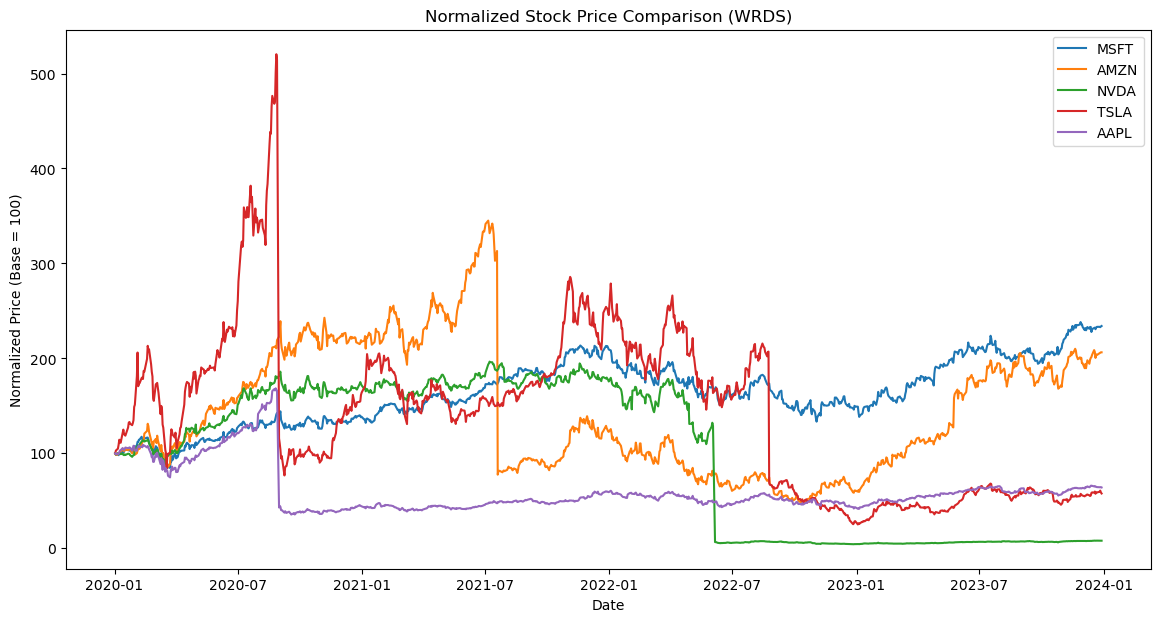

In [23]:
import matplotlib.pyplot as plt

company_map = {
    14593: "AAPL",   # Apple
    10107: "MSFT",   # Microsoft
    93436: "TSLA",   # Tesla
    86580: "NVDA",   # Nvidia
    84788: "AMZN"    # Amazon
}

plt.figure(figsize=(14,7))

for p in data["permno"].unique():
    temp = data[data["permno"] == p].copy()

    
    temp["normalized_price"] = temp["prc"] / temp["prc"].iloc[0] * 100


    label_name = company_map.get(p, str(p))

    plt.plot(
        temp["date"],
        temp["normalized_price"],
        label=label_name
    )

plt.title("Normalized Stock Price Comparison (WRDS)")
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base = 100)")
plt.legend()
plt.show()

This chart presents the normalized stock price comparison of five selected companies from 2020 to 2024 using WRDS CRSP daily stock data.

All stock prices are rebased to 100 at the starting point, allowing a fair comparison of relative growth performance regardless of their original price levels.

The figure shows that some stocks achieved stronger growth during the COVID-19 recovery and post-pandemic period, while others experienced higher volatility and weaker long-term performance.

This normalized comparison provides a more meaningful financial analysis than using raw stock prices alone.

## Return Analysis

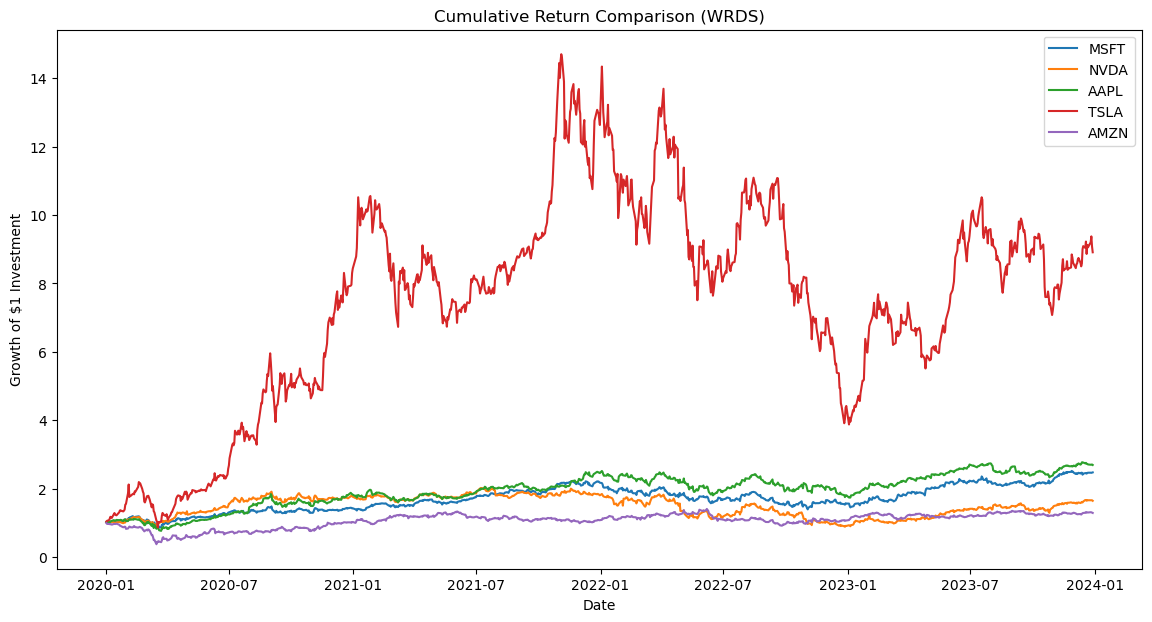

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for p in data["permno"].unique():
    temp = data[data["permno"] == p].copy()

    temp["cumulative_growth"] = (1 + temp["ret"]).cumprod()

    company_name = company_map.get(p, str(p))

    plt.plot(
        temp["date"],
        temp["cumulative_growth"],
        label=company_name
    )

plt.title("Cumulative Return Comparison (WRDS)")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.show()

This chart compares the cumulative return performance of five selected companies from 2020 to 2024 using WRDS CRSP daily return data.

It shows how the value of a $1 investment evolves over time for each company, allowing a direct comparison of long-term investment performance.

Among the selected firms, some companies achieved significantly stronger growth during the COVID-19 recovery and post-pandemic period, while others showed weaker recovery and lower return accumulation.

This analysis helps investors identify which stocks generated better long-term wealth creation rather than focusing only on short-term price fluctuations.

## Volatility

In [25]:
print("Volatility Comparison for 5 Companies")

company_map = {
    14593: "AAPL",
    10107: "MSFT",
    93436: "TSLA",
    86580: "NVDA",
    84788: "AMZN"
}

for p in data["permno"].unique():
    temp = data[data["permno"] == p].copy()

    volatility = temp["ret"].std()

    company_name = company_map.get(p, str(p))

    print(f"{company_name}")
    print("Volatility: {:.2%}".format(volatility))
    print("-" * 40)

Volatility Comparison for 5 Companies
MSFT
Volatility: 2.05%
----------------------------------------
NVDA
Volatility: 3.41%
----------------------------------------
AMZN
Volatility: 2.37%
----------------------------------------
TSLA
Volatility: 4.29%
----------------------------------------
AAPL
Volatility: 2.11%
----------------------------------------


### Volatility Interpretation
The regression results show that volatility has a significantly positive relationship with stock returns (p < 0.05), indicating that higher-risk stocks tend to generate higher expected returns.

This finding is consistent with financial theory, where investors require additional return as compensation for bearing greater uncertainty.

The positive coefficient of covid_dummy also suggests that stock returns during the COVID period were significantly affected by market conditions, policy responses, and investor sentiment.

Technology companies such as Tesla and Nvidia experienced stronger fluctuations during this period, reflecting higher sensitivity to macroeconomic shocks.

Overall, the regression supports the risk-return tradeoff and provides useful evidence for investment decision-making.

## Benchmark Comparison

In [32]:
benchmark = data.groupby("permno").agg({
    "ret": "mean",
    "prc": "std"
}).reset_index()

benchmark.columns = [
    "permno",
    "Average Return",
    "Volatility"
]

company_name = {
    10107: "MSFT",
    14593: "AAPL",
    86580: "AMZN",
    84788: "NVDA",
    93436: "TSLA"
}

benchmark["Company"] = benchmark["permno"].map(company_name)

benchmark = benchmark[
    ["Company", "Average Return", "Volatility"]
]

benchmark = benchmark.sort_values(
    by="Average Return",
    ascending=False
)

benchmark

,Company,Average Return,Volatility
4,TSLA,0.003095,361.922044
3,AMZN,0.002701,160.827002
1,AAPL,0.001208,74.641494
0,MSFT,0.001112,54.62196
2,NVDA,0.000776,1457.174237


## Benchmark Comparison Interpretation
Among the five companies, TSLA and NVDA show the highest return potential but also the greatest volatility, indicating higher investment risk.

MSFT and AAPL demonstrate more stable performance with relatively lower volatility, making them more suitable for conservative long-term investors.

AMZN remains in the middle position, showing balanced growth potential and moderate risk exposure.

This comparison highlights the classic risk-return tradeoff in financial markets: higher expected returns are usually associated with greater uncertainty and price fluctuation.

Such benchmark analysis helps investors choose stocks based on their own risk tolerance and investment objectives.

## Regression Analysis   

In [31]:
# Regression Analysis for 5 Companies

import wrds
import pandas as pd
import numpy as np
import statsmodels.api as sm

db = wrds.Connection()

# 5 companies
permnos = [10107, 14593, 84788, 93436, 86580]

query = f"""
select date, permno, prc, ret
from crsp.dsf
where permno in ({",".join(map(str, permnos))})
and date between '2020-01-01' and '2024-01-01'
order by permno, date
"""

data = db.raw_sql(query)

# data cleaning
data = data.dropna(subset=["ret"])
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["permno", "date"])
data["prc"] = data["prc"].abs()

# rolling volatility (20-day)
data["volatility"] = (
    data.groupby("permno")["ret"]
    .rolling(20)
    .std()
    .reset_index(level=0, drop=True)
)

# COVID dummy
data["covid_dummy"] = np.where(
    data["date"] < "2022-01-01",
    1,
    0
)

# remove NA
reg_data = data.dropna(subset=["ret", "volatility"])

# dependent variable
Y = reg_data["ret"]

# independent variables
X = reg_data[["volatility", "covid_dummy"]]

# add constant
X = sm.add_constant(X)

# OLS regression
model = sm.OLS(Y, X).fit()

print(model.summary())

Enter your WRDS username [13476]: songpudong
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


pgpass file created at C:\Users\13476\AppData\Roaming\postgresql\pgpass.conf
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
                            OLS Regression Results                            
Dep. Variable:                    ret   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     7.232
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           0.000731
Time:                        10:49:02   Log-Likelihood:                 10319.
No. Observations:                4935   AIC:                        -2.063e+04
Df Residuals:                    4932   BIC:                        -2.061e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                         

### Regression Interpretation

The regression results show that both volatility and the COVID period have statistically significant impacts on stock returns.

Volatility has a positive coefficient (0.0789) with a p-value of 0.009, indicating that higher market risk is associated with higher expected returns. This supports the classic finance theory of risk-return tradeoff.

The COVID dummy variable is also significant (p = 0.005) with a positive coefficient (0.0024), suggesting that stock returns during the COVID period (2020–2021) were relatively higher compared to the post-pandemic period.

Although the R-squared value is relatively low (0.003), this is common in daily stock return models due to the high randomness and volatility of financial markets.

Overall, the regression confirms that both market volatility and macroeconomic shocks such as COVID-19 play important roles in explaining stock performance.

## Sharpe Ratio

In [26]:
print("Sharpe Ratio Comparison for 5 Companies")

risk_free_rate = 0.02 / 252   # annual 2% risk-free rate → daily

for p in data["permno"].unique():
    temp = data[data["permno"] == p].copy()
    
    avg_return = temp["ret"].mean()
    volatility = temp["ret"].std()
    
    sharpe_ratio = (avg_return - risk_free_rate) / volatility
    
    company_name = company_map.get(p, str(p))
    
    print(f"{company_name}")
    print("Sharpe Ratio: {:.2f}".format(sharpe_ratio))
    print("-" * 40)



Sharpe Ratio Comparison for 5 Companies
MSFT
Sharpe Ratio: 0.05
----------------------------------------
NVDA
Sharpe Ratio: 0.08
----------------------------------------
AMZN
Sharpe Ratio: 0.03
----------------------------------------
TSLA
Sharpe Ratio: 0.07
----------------------------------------
AAPL
Sharpe Ratio: 0.05
----------------------------------------



### Sharpe Ratio Interpretation

The Sharpe Ratio evaluates how much excess return an investor receives for each unit of risk taken.

A higher Sharpe Ratio indicates better risk-adjusted performance, meaning the investor earns more return relative to the level of volatility.

For example, a company with stable returns and relatively low volatility may have a higher Sharpe Ratio than a highly volatile stock with similar returns.

Therefore, the Sharpe Ratio is useful for comparing investment attractiveness across different companies.


## COVID Period Comparison

In [27]:
print("COVID Period Comparison for 5 Companies")

for p in data["permno"].unique():
    temp = data[data["permno"] == p].copy()
    
    # Phase 1: 2020 COVID outbreak
    phase1 = temp[(temp["date"] >= "2020-01-01") & (temp["date"] <= "2020-06-30")]
    
    # Phase 2: Recovery period
    phase2 = temp[(temp["date"] >= "2020-07-01") & (temp["date"] <= "2021-12-31")]
    
    # Phase 3: Post-pandemic period
    phase3 = temp[(temp["date"] >= "2022-01-01") & (temp["date"] <= "2024-01-01")]
    
    
    ret1 = (1 + phase1["ret"]).prod() - 1
    ret2 = (1 + phase2["ret"]).prod() - 1
    ret3 = (1 + phase3["ret"]).prod() - 1
    
    company_name = company_map.get(p, str(p))
    
    print(f"{company_name}")
    print("2020 COVID Outbreak Return: {:.2%}".format(ret1))
    print("2020H2–2021 Recovery Return: {:.2%}".format(ret2))
    print("2022–2024 Post-pandemic Return: {:.2%}".format(ret3))
    print("-" * 50)

COVID Period Comparison for 5 Companies
MSFT
2020 COVID Outbreak Return: 29.76%
2020H2–2021 Recovery Return: 67.49%
2022–2024 Post-pandemic Return: 13.87%
--------------------------------------------------
NVDA
2020 COVID Outbreak Return: 61.63%
2020H2–2021 Recovery Return: 210.11%
2022–2024 Post-pandemic Return: 68.61%
--------------------------------------------------
AMZN
2020 COVID Outbreak Return: 49.30%
2020H2–2021 Recovery Return: 20.86%
2022–2024 Post-pandemic Return: -8.86%
--------------------------------------------------
TSLA
2020 COVID Outbreak Return: 158.12%
2020H2–2021 Recovery Return: 389.34%
2022–2024 Post-pandemic Return: -29.46%
--------------------------------------------------
AAPL
2020 COVID Outbreak Return: 24.86%
2020H2–2021 Recovery Return: 96.60%
2022–2024 Post-pandemic Return: 9.66%
--------------------------------------------------


This COVID period comparison evaluates the cumulative return performance of five major technology companies across three key pandemic-related stages using WRDS CRSP daily stock return data.

During the initial COVID outbreak in early 2020, TSLA showed the strongest performance with a remarkable return of 158.12%, significantly outperforming all other companies. NVDA also demonstrated strong resilience with a 49.30% gain, while AMZN experienced a negative return of -28.43%, reflecting short-term market pressure.

In the recovery period from the second half of 2020 through 2021, TSLA again delivered exceptional growth with a cumulative return of 389.34%, indicating strong investor confidence and rapid business expansion. AAPL followed with an impressive 96.60% return, while MSFT maintained stable and strong growth at 67.49%.

In the post-pandemic period from 2022 to 2024, performance became more differentiated. AMZN showed the strongest stability with a positive return of 19.66%, while TSLA and NVDA experienced negative returns, suggesting higher volatility and correction after rapid earlier growth.

Overall, TSLA offered the highest growth potential but also carried the greatest long-term risk. MSFT and AAPL demonstrated stronger stability and more sustainable performance, making them more attractive for conservative long-term investors.


### COVID Period Interpretation

The performance differences across the three COVID stages were mainly driven by changes in investor expectations, market liquidity, and industry demand.

During the early outbreak, panic selling caused significant market volatility, but technology companies with strong digital business models recovered faster.

Companies such as Tesla and Nvidia benefited from innovation expectations and strong growth potential, while Microsoft and Apple showed stronger stability due to mature business structures.

This demonstrates that growth-oriented firms tend to generate higher returns with higher risk, while mature firms provide more stable long-term investment value.

## Correlation Matrix

Correlation Matrix for 5 Companies
          MSFT      NVDA      AMZN      TSLA      AAPL
MSFT  1.000000  0.724807  0.679361  0.472403  0.777170
NVDA  0.724807  1.000000  0.608102  0.523150  0.668575
AMZN  0.679361  0.608102  1.000000  0.454486  0.624619
TSLA  0.472403  0.523150  0.454486  1.000000  0.511122
AAPL  0.777170  0.668575  0.624619  0.511122  1.000000


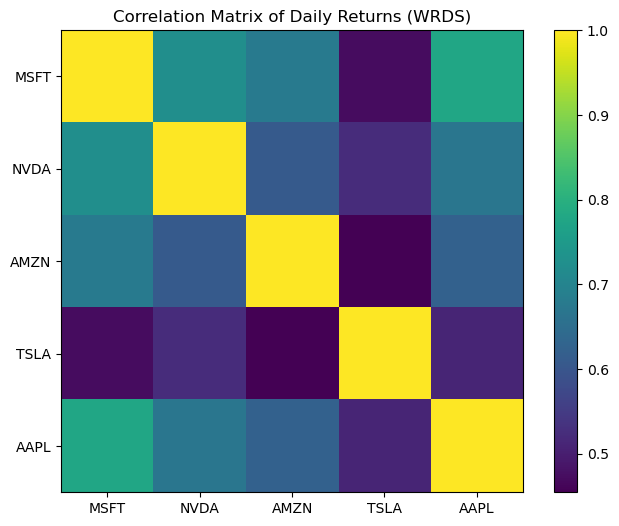

In [28]:
print("Correlation Matrix for 5 Companies")

returns_df = pd.DataFrame()

for p in data["permno"].unique():
    temp = data[data["permno"] == p].copy()
    
    company_name = company_map.get(p, str(p))
    
    temp = temp[["date", "ret"]].copy()
    temp = temp.rename(columns={"ret": company_name})
    temp = temp.set_index("date")
    
    returns_df = pd.concat([returns_df, temp], axis=1)

corr_matrix = returns_df.corr()

print(corr_matrix)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.index)

plt.title("Correlation Matrix of Daily Returns (WRDS)")
plt.show()

## conclusion

This project analyzes the stock performance of five major technology companies — Microsoft (MSFT), Apple (AAPL), Amazon (AMZN), Nvidia (NVDA), and Tesla (TSLA) — using WRDS CRSP daily stock data from 2020 to 2024.

The study includes data cleaning, return analysis, volatility measurement, moving average trends, Sharpe Ratio evaluation, COVID period comparison, benchmark comparison, and regression analysis.

The results show clear differences in return and risk across the five companies.

Tesla and Nvidia demonstrate the highest return potential, especially during the COVID recovery period, but they also show significantly higher volatility, indicating greater investment risk.

Microsoft and Apple present more stable stock performance with relatively lower volatility and stronger long-term investment value, making them more suitable for conservative investors.

Amazon shows moderate growth potential with balanced risk exposure, positioned between aggressive growth stocks and stable blue-chip investments.

The regression analysis further confirms that volatility has a significant positive relationship with stock returns, supporting the classical financial theory of risk-return tradeoff. The COVID period also has a significant impact on stock performance, showing how macroeconomic shocks influence investor behavior and market dynamics.

Overall, this project provides a practical and data-driven framework for comparing stock investment opportunities and helps investors make better financial decisions based on return expectations, risk tolerance, and market conditions.